<a href="https://colab.research.google.com/github/greapis/Tensorflow_Python/blob/Supervised-Learning/Logistics_regression_Titinic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style = "white", color_codes =True)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
try:
  df = pd.read_csv('/content/drive/MyDrive/supervisedlearning/Titanic-Dataset.csv')
  print("File read successfully!")
except FileNotFoundError:
  print("Please upload the file 'titanic-Dataset.csv' to the Colab environment.")

File read successfully!


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
len(df.PassengerId.unique())

891

In [7]:
df.drop(columns=["PassengerId"], inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [16]:
df.head(10)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [33]:
df.Survived.unique(), df.Survived.value_counts()

(array([0, 1]),
 Survived
 0    549
 1    342
 Name: count, dtype: int64)

(array([0, 1]), <Axes: ylabel='count'>)

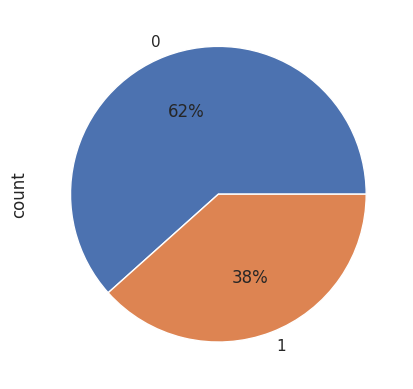

In [34]:
df.Survived.unique(), df.Survived.value_counts().plot.pie(autopct="%1.0f%%")

(array(['male', 'female'], dtype=object), <Axes: ylabel='count'>)

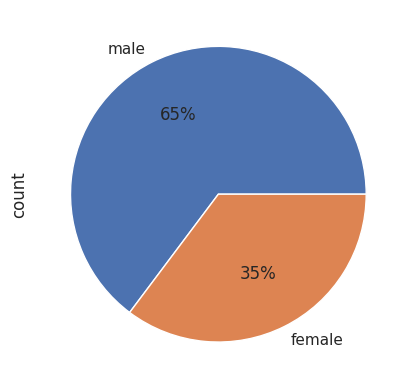

In [41]:
df.Sex.unique(), df.Sex.value_counts().plot.pie(autopct = "%1.0f%%")

In [25]:
df.Age.unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [45]:
df["Age"].dropna().isnull()

,Age
0,False
1,False
2,False
3,False
4,False
...,...
885,False
886,False
887,False
889,False


In [55]:
un_logic_age = []
index_unLogic_Age = []
for age in df["Age"].dropna().index:
  if df["Age"].dropna()[age] < 1:
    un_logic_age.append(df["Age"].dropna()[age])
    index_unLogic_Age.append(age)

In [56]:
print(f"Val of un_logic_age : {un_logic_age}")
print(f"Val of index_unLogic_Age : {index_unLogic_Age}")

Val of un_logic_age : []
Val of index_unLogic_Age : []


In [60]:
df.drop(index=index_unLogic_Age, inplace=True)

In [66]:
df.Age.min()

1.0

In [71]:
df.shape[0] - df[df['Age'].isna()].shape[0]

707

In [68]:
df.Age.dropna().shape[0]

707

You can upload your file by clicking the folder icon on the left sidebar, then clicking the upload icon. Once uploaded, the file should appear in the file browser. You can then copy the path to the file.

In [9]:
# After uploading, you can read the file like this:
try:
    df = pd.read_csv("/content/titanic-Dataset.csv")
    print("File read successfully!")
except FileNotFoundError:
    print("Please upload the file 'titanic-Dataset.csv' to the Colab environment.")

Please upload the file 'titanic-Dataset.csv' to the Colab environment.
